In [1]:
import sys
print(sys.executable)

c:\Users\user\OneDrive\Desktop\speechbanana\.venv\Scripts\python.exe


In [2]:
%pip install tensorflow
%pip install pandas
%pip install numpy matplotlib seaborn pillow scikit-learn

  Using cached tensorflow-2.20.0-cp312-cp312-win_amd64.whl.metadata (4.6 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-6.33.2-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached termcolor-3.2.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached wrapt-2.0.1-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
  Using cached

In [1]:
import os
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

from sklearn.metrics import classification_report, confusion_matrix

c:\Users\user\OneDrive\Desktop\speechbanana\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
print(tf.__version__)


2.20.0


In [4]:
# ==========================
# 0. CONFIG
# ==========================
BASE_DIR = "dataset_split.1"         # change if different
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE = (299, 299)
BATCH_SIZE = 32
EPOCHS = 25

MODEL_SAVE_PATH = "audiogram_severity_model1.2.keras"
CLASS_MAP_PATH = "class_indices.json"


print("TensorFlow:", tf.__version__)
print("Train dir:", TRAIN_DIR)
print("Test dir :", TEST_DIR)

TensorFlow: 2.20.0
Train dir: dataset_split.1\train
Test dir : dataset_split.1\test


In [ ]:

# 1. Data generators (folders) 

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,              # increased from 10
    width_shift_range=0.15,         # increased from 0.08
    height_shift_range=0.15,        # increased from 0.08
    zoom_range=0.15,                # increased from 0.08
    shear_range=0.1,                # increased from 0.05
    brightness_range=[0.8, 1.2],    # NEW: brightness variations
    fill_mode='reflect',             # better than default
    horizontal_flip=False,          # audiograms usually shouldn't flip
    validation_split=0.2            # take 20% of TRAIN as validation
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print("\nClasses:", train_generator.class_indices)

# Save mapping for later inference
with open(CLASS_MAP_PATH, "w") as f:
    json.dump(train_generator.class_indices, f)
print("Saved class mapping to:", CLASS_MAP_PATH)

Found 511 images belonging to 6 classes.
Found 123 images belonging to 6 classes.
Found 199 images belonging to 6 classes.

Classes: {'Mild': 0, 'Moderate': 1, 'Moderately severe': 2, 'Normal': 3, 'Profound': 4, 'Severe': 5}
Saved class mapping to: class_indices.json


In [6]:
# Class weights to help with imbalance
from sklearn.utils.class_weight import compute_class_weight

class_labels = list(train_generator.class_indices.keys())
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.array(class_labels),
    y=[class_labels[i] for i in train_generator.classes],
)
class_weight = {i: w for i, w in enumerate(class_weights_arr)}
print("Class weights:", class_weight)


Class weights: {0: np.float64(0.8268608414239482), 1: np.float64(0.8602693602693603), 2: np.float64(0.9789272030651341), 3: np.float64(0.8268608414239482), 4: np.float64(1.9356060606060606), 5: np.float64(1.1355555555555557)}


In [7]:
# ==========================
# 2. Build model (Transfer learning) - IMPROVED
# ==========================
base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_model.trainable = False  # freeze first

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu", kernel_regularizer=l2(0.001))(x)  # NEW: L2 regularization
x = BatchNormalization()(x)  # NEW: Batch normalization
x = Dropout(0.5)(x)  # increased from 0.4
preds = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=preds)

model.compile(
    optimizer=Adam(learning_rate=5e-5),  # reduced from 1e-4
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 22,856,998 (87.19 MB)

 Trainable params: 1,053,190 (4.02 MB)

 Non-trainable params: 21,803,808 (83.17 MB)

In [10]:
# ==========================
# 3. Callbacks
# ==========================
checkpoint_path = "audiogram_severity_model1.2.keras"
callbacks = [
    ModelCheckpoint(checkpoint_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
]


In [11]:
# ==========================
# 4. Train (frozen base)
# ==========================
EPOCHS = 25
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1,
)

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1551 - loss: 3.3983
Epoch 1: val_accuracy improved from None to 0.21951, saving model to audiogram_severity_model1.2.keras

Epoch 1: finished saving model to audiogram_severity_model1.2.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.1820 - loss: 3.2757 - val_accuracy: 0.2195 - val_loss: 2.5634 - learning_rate: 5.0000e-05
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2259 - loss: 2.9749
Epoch 2: val_accuracy did not improve from 0.21951
16/16 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.2975 - loss: 2.7758 - val_accuracy: 0.2114 - val_loss: 2.4756 - learning_rate: 5.0000e-05
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3616 - loss: 2.4924
Epoch 3: val_accuracy improved from 0.21951 to 0.30894, saving model to audiogram_severity_model1.2.keras

Epoch 3: finished saving model to audiogram_severity_model1.2.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.3268 - loss: 2

In [12]:
# ==========================
# 4b. Fine-tune: unfreeze top layers and continue training - IMPROVED
# ==========================
fine_tune_at = 100  # reduced from 200 (unfreeze more layers for better accuracy)

base_model.trainable = True
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=5e-6),  # reduced from 1e-5
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

FINE_TUNE_EPOCHS = 25  # increased from 15
history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1,
)

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1700 - loss: 3.3251
Epoch 1: val_accuracy did not improve from 0.67480
16/16 ━━━━━━━━━━━━━━━━━━━━ 124s 6s/step - accuracy: 0.2055 - loss: 3.2556 - val_accuracy: 0.4553 - val_loss: 1.9590 - learning_rate: 5.0000e-06
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2448 - loss: 3.1582
Epoch 2: val_accuracy did not improve from 0.67480
16/16 ━━━━━━━━━━━━━━━━━━━━ 91s 6s/step - accuracy: 0.2603 - loss: 3.1547 - val_accuracy: 0.3089 - val_loss: 2.1315 - learning_rate: 5.0000e-06
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2379 - loss: 3.0231
Epoch 3: val_accuracy did not improve from 0.67480

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-06.
16/16 ━━━━━━━━━━━━━━━━━━━━ 90s 6s/step - accuracy: 0.2309 - loss: 3.0483 - val_accuracy: 0.3171 - val_loss: 2.2240 - learning_rate: 5.0000e-06
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2743 - loss: 2.9845
Epoch 4

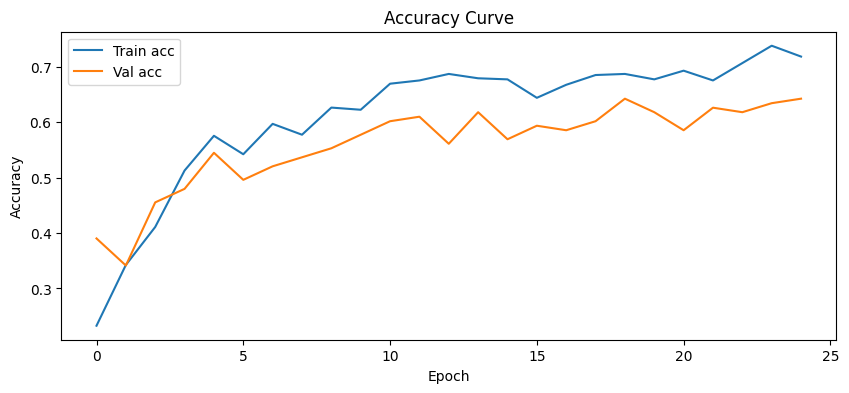

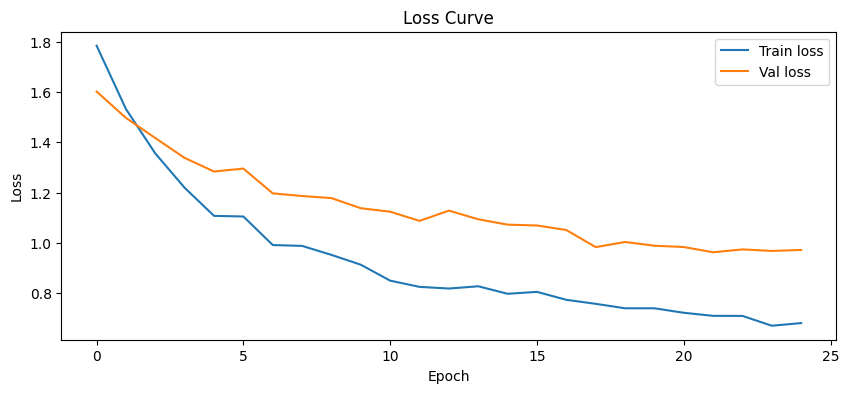

7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.4925 - loss: 1.1739

✅ Test accuracy: 49.25% | Test loss: 1.1739


In [13]:
# ==========================
# 5. Plot curves
# ==========================
plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"], label="Train acc")
plt.plot(history.history["val_accuracy"], label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

# ==========================
# 6. Evaluate on TEST
# ==========================
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\n✅ Test accuracy: {test_acc*100:.2f}% | Test loss: {test_loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step

Classification Report:
                   precision    recall  f1-score   support

             Mild       0.42      0.55      0.47        40
         Moderate       0.47      0.36      0.41        39
Moderately severe       0.34      0.68      0.45        34
           Normal       1.00      0.28      0.43        40
         Profound       0.90      0.53      0.67        17
           Severe       0.63      0.59      0.61        29

         accuracy                           0.48       199
        macro avg       0.62      0.50      0.51       199
     weighted avg       0.60      0.48      0.48       199



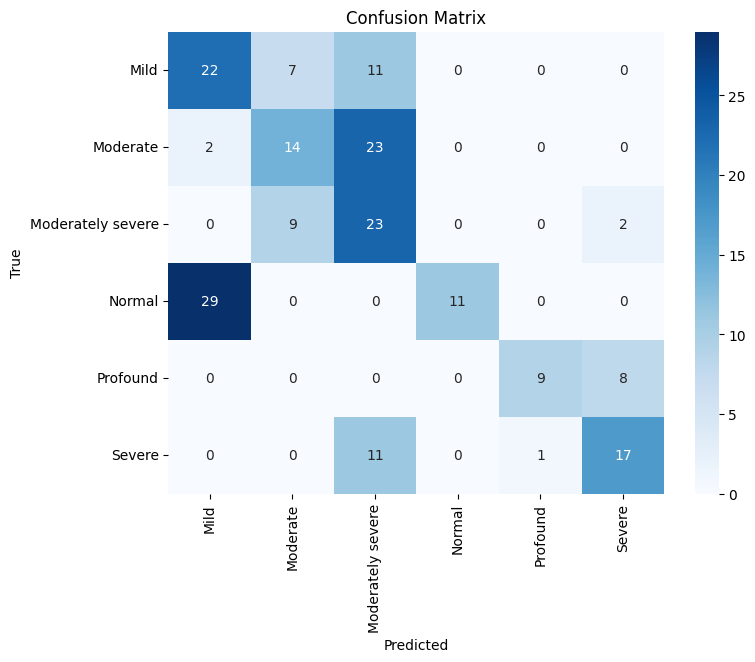

In [13]:
# ==========================
# 7. Classification report + Confusion matrix
# ==========================
test_generator.reset()
pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes

# index->label mapping
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
target_names = [idx_to_class[i] for i in range(len(idx_to_class))]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=target_names,
            yticklabels=target_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [14]:
# Backup old model before saving new one
if os.path.exists(MODEL_SAVE_PATH):
    backup_path = MODEL_SAVE_PATH.replace('.keras', '_backup.keras')
    shutil.copy(MODEL_SAVE_PATH, backup_path)
    print(f"✅ Backed up old model to: {backup_path}")

model.save(MODEL_SAVE_PATH)
print("\n✅ Saved trained model to:", MODEL_SAVE_PATH)
print("✅ Saved class mapping to:", CLASS_MAP_PATH)
print("\n📊 Model improvements applied:")
print("   • Stronger data augmentation (rotation, shift, zoom, brightness)")
print("   • L2 regularization (0.001)")
print("   • Batch normalization layer")
print("   • Increased dropout (0.5)")
print("   • Lower learning rates (5e-5 initial, 5e-6 fine-tune)")
print("   • More fine-tuning layers unfrozen (fine_tune_at=100)")
print("   • Extended fine-tuning epochs (25)")

✅ Backed up old model to: audiogram_severity_model1.2_backup.keras

✅ Saved trained model to: audiogram_severity_model1.2.keras
✅ Saved class mapping to: class_indices.json

📊 Model improvements applied:
   • Stronger data augmentation (rotation, shift, zoom, brightness)
   • L2 regularization (0.001)
   • Batch normalization layer
   • Increased dropout (0.5)
   • Lower learning rates (5e-5 initial, 5e-6 fine-tune)
   • More fine-tuning layers unfrozen (fine_tune_at=100)
   • Extended fine-tuning epochs (25)


In [16]:
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import preprocess_input

IMG_SIZE = (299, 299)

# Load model + class mapping
model = load_model("audiogram_severity_model1.2.keras")

with open("class_indices.json", "r") as f:
    class_indices = json.load(f)

# Reverse mapping: index -> label
idx_to_class = {v: k for k, v in class_indices.items()}

def predict_severity(image_path: str):
    img = load_img(image_path, target_size=IMG_SIZE)
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)  # IMPORTANT for InceptionV3

    probs = model.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_label = idx_to_class[pred_idx]
    confidence = float(probs[pred_idx])

    return pred_label, confidence, probs